# Phase 2b
The first parts of the code can be ignored as it is adopted from phase 2a to build up the structure

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pulser
from pulser import Register, Sequence
from pulser.backend import BitStrings
from pulser.devices import MockDevice
from pulser.pulse import Pulse
from pulser.waveforms import ConstantWaveform, RampWaveform
from pulser_pasqal import PasqalCloud
from pasqal_cloud import SDK

L=7
N=L*L
SHOTS=1000
DT_NS=10
CHI_MAIN=50
CHI_CHECK=100
OMEGA_OVER_2PI_MHZ=2.0
TARGET_DX_OVER_J1=1.08
FIELDS=np.array([1.,2.,2.5,2.75,3.,3.25,3.5,3.625,3.75,3.875,4.,4.125,4.25,4.375,4.5,4.625,4.875,5.,5.125,5.25,5.375,5.5,5.625,5.875,6.,8.,10.])
CHECK_FIELDS=np.array([3.5,4.0,4.5,5.0])
CREDENTIALS_FILE='credentials.example.yaml'
BATCH_FILE=Path('phase2_paper_pulse_batches.json')
SUBMIT_NEW_JOBS=False
print('Pulser',pulser.__version__,'| fields',len(FIELDS))

Pulser 1.8.0 | fields 27


/var/folders/_6/q64xkrh52091t3lfmz_7yn400000gn/T/ipykernel_22659/1566367274.py:12: DeprecationWarning: This package is replaced by pasqal-cloud (https://pypi.org/project/pasqal-cloud/) and is going to be removed in the future.
  from pulser_pasqal import PasqalCloud


In [3]:
omega=2*np.pi*OMEGA_OVER_2PI_MHZ
u1=omega/(TARGET_DX_OVER_J1/2)
spacing=MockDevice.rydberg_blockade_radius(u1)
e1=spacing*np.array([1.,0.]);e2=spacing*np.array([.5,np.sqrt(3)/2])
ij=np.array([(i,j) for i in range(L) for j in range(L)])
xy=np.array([i*e1+j*e2 for i,j in ij])
register=Register.from_coordinates(xy,prefix='q')
r=np.linalg.norm(xy[:,None,:]-xy[None,:,:],axis=-1)
u=np.zeros_like(r);mask=r>0;u[mask]=MockDevice.interaction_coeff/r[mask]**6
delta_u=np.triu(u,1).sum()/N
local_delta_u=.5*u.sum(axis=1)
pair_r=r[np.triu_indices(N,1)]/spacing;pair_u=u[np.triu_indices(N,1)]/u1
print(f'spacing={spacing:.3f} µm, u1/2π={u1/(2*np.pi):.3f} MHz')
print(f'Omega/u1={omega/u1:.3f}, Delta_x/J1={2*omega/u1:.3f}')
print(f'global delta_U/u1={delta_u/u1:.3f}')
for shell in [1.,np.sqrt(3),2.,np.sqrt(7)]:
    m=np.isclose(pair_r,shell,rtol=1e-5)
    print(f'r/a={shell:.6f}: U/U1={pair_u[m].mean():.6f}, pairs={m.sum()}')
assert np.isclose(2*omega/u1,1.08)
assert np.isclose(pair_u[np.isclose(pair_r,np.sqrt(3),rtol=1e-5)].mean(),1/27,rtol=1e-4)

spacing=7.844 µm, u1/2π=3.704 MHz
Omega/u1=0.540, Delta_x/J1=1.080
global delta_U/u1=2.565
r/a=1.000000: U/U1=1.000000, pairs=120
r/a=1.732051: U/U1=0.037037, pairs=96
r/a=2.000000: U/U1=0.015625, pairs=95
r/a=2.645751: U/U1=0.002915, pairs=148


bulk indices [ 8  9 10 11 12 15 16 17 18 19 22 23 24 25 26 29 30 31 32 33 36 37 38 39
 40]
mean bulk delta_U/u1 3.1469788884490235 | global 2.5651197360663702


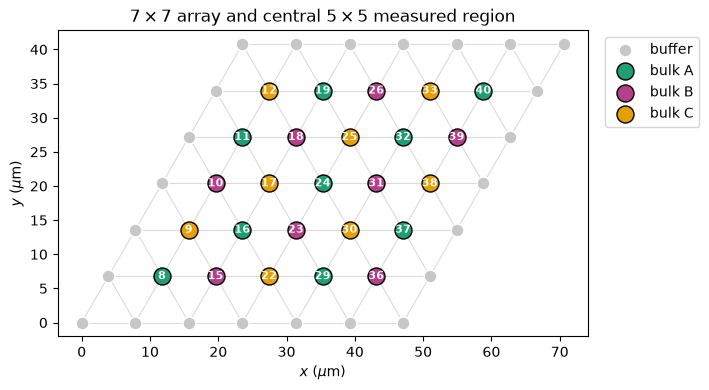

In [4]:
bulk_mask=(ij[:,0]>=1)&(ij[:,0]<=5)&(ij[:,1]>=1)&(ij[:,1]<=5)
bulk_indices=np.flatnonzero(bulk_mask);Nb=len(bulk_indices)
bulk_ij=ij[bulk_indices];bulk_colours=(bulk_ij[:,0]-bulk_ij[:,1])%3
all_colours=(ij[:,0]-ij[:,1])%3
assert Nb==25 and np.array_equal(np.sort(np.bincount(bulk_colours,minlength=3)),[8,8,9])
palette=np.array(['#1D9E75','#B4408B','#E69F00'])
fig,ax=plt.subplots(figsize=(7.2,6.2))
for i in range(N):
    for j in range(i+1,N):
        if np.isclose(r[i,j],spacing,rtol=1e-6): ax.plot(xy[[i,j],0],xy[[i,j],1],color='.86',lw=.8,zorder=0)
ax.scatter(xy[~bulk_mask,0],xy[~bulk_mask,1],s=85,color='.78',edgecolor='white',label='buffer',zorder=2)
for colour,label in enumerate('ABC'):
    m=bulk_mask&(all_colours==colour)
    ax.scatter(xy[m,0],xy[m,1],s=150,color=palette[colour],edgecolor='black',label=f'bulk {label}',zorder=3)
for index in bulk_indices: ax.text(*xy[index],str(index),ha='center',va='center',fontsize=8,color='white',fontweight='bold',zorder=4)
ax.set_aspect('equal');ax.set_xlabel(r'$x$ ($\mu$m)');ax.set_ylabel(r'$y$ ($\mu$m)')
ax.set_title(r'$7\times7$ array and central $5\times5$ measured region');ax.legend(bbox_to_anchor=(1.02,1));fig.tight_layout()
print('bulk indices',bulk_indices)
print('mean bulk delta_U/u1',local_delta_u[bulk_indices].mean()/u1,'| global',delta_u/u1)

initial field 11.13023947213274 target detuning/u1 0.56511973606637


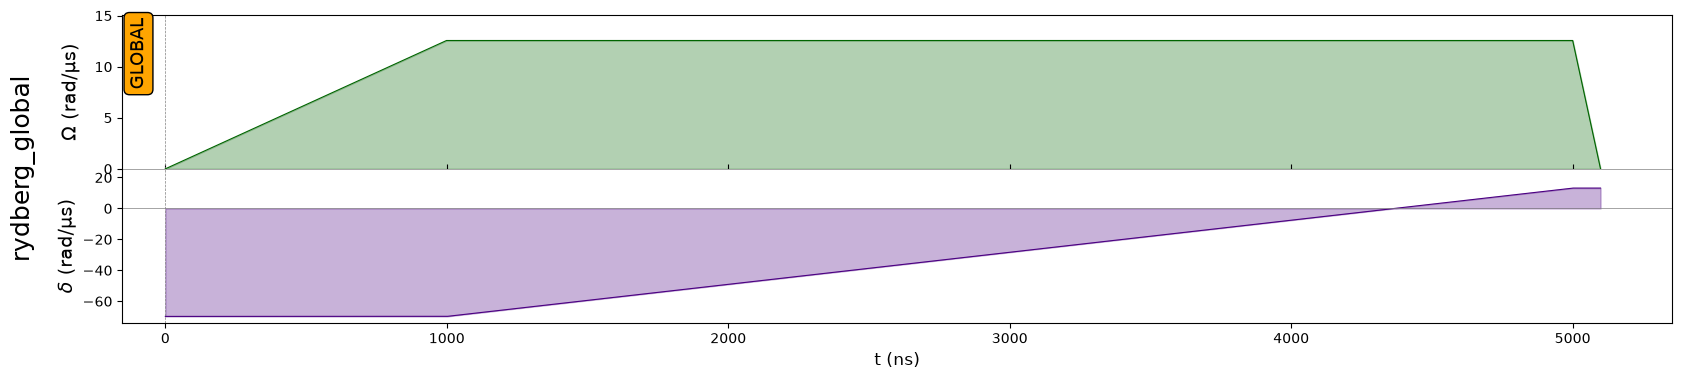

In [5]:
def material_to_detuning(field): return delta_u-.5*field*u1
def detuning_to_material(delta): return 2*(delta_u-delta)/u1
def build_sequence(field):
    di=-3*u1;df=material_to_detuning(field)
    seq=Sequence(register,MockDevice);seq.declare_channel('rydberg_global','rydberg_global')
    seq.add(Pulse(RampWaveform(1000,0,omega),ConstantWaveform(1000,di),0),'rydberg_global')
    seq.add(Pulse(ConstantWaveform(4000,omega),RampWaveform(4000,di,df),0),'rydberg_global')
    seq.add(Pulse(RampWaveform(100,omega,0),ConstantWaveform(100,df),0),'rydberg_global')
    return seq
test_fields=np.array([1.,4.,10.]);assert np.allclose([detuning_to_material(material_to_detuning(x)) for x in test_fields],test_fields)
representative=4.;print('initial field',detuning_to_material(-3*u1),'target detuning/u1',material_to_detuning(representative)/u1)
build_sequence(representative).draw()

In [6]:
SUBMIT_NEW_JOBS=False

def cloud_connection():
    c=yaml.safe_load(Path(CREDENTIALS_FILE).read_text())
    return PasqalCloud(username=c['username'],project_id=c['project_id'],password=c['password'])
def submit_one(connection,field,chi):
    cfg=pulser.backend.EmulationConfig(observables=(BitStrings(evaluation_times=[1.0],num_shots=SHOTS),),dt=DT_NS,max_bond_dim=chi)
    return pulser.backends.EmuMPSBackend(build_sequence(field),config=cfg,connection=connection).run().batch_id
if SUBMIT_NEW_JOBS:
    if BATCH_FILE.exists(): raise FileExistsError(f'{BATCH_FILE} exists; refusing duplicate submission.')
    connection=cloud_connection()
    batches={'metadata':{'L':L,'shots':SHOTS,'dt_ns':DT_NS,'chi_main':CHI_MAIN,'chi_check':CHI_CHECK},'chi50':{},'chi100':{}}
    for field in FIELDS:
        bid=submit_one(connection,float(field),CHI_MAIN);batches['chi50'][str(float(field))]=bid;print('chi50',field,bid)
    for field in CHECK_FIELDS:
        bid=submit_one(connection,float(field),CHI_CHECK);batches['chi100'][str(float(field))]=bid;print('chi100',field,bid)
    BATCH_FILE.write_text(json.dumps(batches,indent=2));print('saved',BATCH_FILE)
else:
    print('Submission disabled. Inspect first; set SUBMIT_NEW_JOBS=True once when ready.')

Submission disabled. Inspect first; set SUBMIT_NEW_JOBS=True once when ready.


# Phase 2b: Probing the Classical Frontier with a Quench

Phase 2a reproduced the equilibrium magnetisation — a fidelity check, since classical methods
(DMRG, QMC) prepare ground states well too. To show where a quantum simulator becomes *necessary*,
we turn to real-time post-quench dynamics.

The limitation we demonstrate is of the **classical emulator, not the simulator.** Tensor-network
emulators (emu-mps) compress the state with a bond dimension χ. After a quench, entanglement grows
with time, so the χ needed for accuracy grows too — until no achievable χ suffices and the
emulation fails. A quantum device compresses nothing, so it continues where the emulator cannot.

**Paper (Fig. 4):** from |↑…↑⟩, quench the field and track C₁ᶻᶻ(t), benchmarking against TDVP-MPS
up to D=600. The bond dimension needed for convergence grows with time — ~2 weeks classical vs
~1 day on the QPU. We reproduce this at small scale, using the *disagreement between χ values* as a
measurable signature of where the emulation breaks down.

## Setup: quench protocol and pulses

Opposite to the adiabatic sweep: instead of changing the Hamiltonian slowly to stay in the ground
state, we change it *suddenly* to drive dynamics. Three stages (paper Fig. S2B):

1. **Fast ramp-up** (20 ns) — sudden switch-on of Ω and δ. Start state |↑…↑⟩ is not an eigenstate,
   so it evolves.
2. **Hold** — Ω, δ constant for a variable evolution time; all dynamics happen here. Scanning the
   hold traces C₁ᶻᶻ(t).
3. **Fast ramp-down** — freeze the z-basis for readout.

Observable: nearest-neighbour correlator C₁ᶻᶻ = ⟨σᵢᶻσⱼᶻ⟩ averaged over bulk NN bonds (same
edge-protected bulk as Phase 2a). We sweep **quench hardness (Δz/J₁)** and **bond dimension (χ)** —
harder quenches build entanglement faster; disagreement across χ exposes the breakdown.

In [7]:
import itertools

# --- SWEEP AXES  ---
SWEEP_FIELDS = [1.0, 2.0, 3.0, 3.5, 4.0]        # quench hardness (lower = harder = more entanglement)
SWEEP_CHI = [50, 100, 200]         # bond dimensions; pairs are compared for divergence
SWEEP_TIMES_NS = np.array([100, 300, 600, 1000, 1500, 2200, 3000])  # evolution times
RAMP_NS = 20

SWEEP_BATCH_FILE = Path('phase2_quench_sweep2.json')

# --- job count  ---
n_jobs = len(SWEEP_FIELDS) * len(SWEEP_CHI) * len(SWEEP_TIMES_NS)
print(f"GRID: {len(SWEEP_FIELDS)} fields x {len(SWEEP_CHI)} chi x {len(SWEEP_TIMES_NS)} times")
print(f"==> {n_jobs} TOTAL CLOUD JOBS <==   (each is real-time dynamics = the expensive kind)")
print("Reduce any axis if this is too many for your overnight credit/queue budget.")

# --- quench sequence  ---
def build_quench_sequence(field, evolution_ns, ramp_ns=RAMP_NS):
    df = material_to_detuning(field)
    seq = Sequence(register, MockDevice)
    seq.declare_channel('rydberg_global', 'rydberg_global')
    seq.add(Pulse(RampWaveform(ramp_ns, 0, omega), RampWaveform(ramp_ns, 0, df), 0), 'rydberg_global')
    seq.add(Pulse(ConstantWaveform(evolution_ns, omega), ConstantWaveform(evolution_ns, df), 0), 'rydberg_global')
    seq.add(Pulse(RampWaveform(ramp_ns, omega, 0), ConstantWaveform(ramp_ns, df), 0), 'rydberg_global')
    return seq

# --- NN correlator  ---
_bulk_set = set(bulk_indices.tolist())
nn_bonds = np.array([(a, b) for a in range(N) for b in range(a + 1, N)
                     if np.isclose(r[a, b], spacing, rtol=1e-6)
                     and a in _bulk_set and b in _bulk_set])

def C1_zz_from_counts(counts):
    rows = []
    for b, mult in counts.items():
        rows.extend([np.fromiter((int(x) for x in b), dtype=np.int8)] * mult)
    sigma = 1 - 2 * np.asarray(rows, float)
    return float((sigma[:, nn_bonds[:, 0]] * sigma[:, nn_bonds[:, 1]]).mean())

GRID: 5 fields x 3 chi x 7 times
==> 105 TOTAL CLOUD JOBS <==   (each is real-time dynamics = the expensive kind)
Reduce any axis if this is too many for your overnight credit/queue budget.


In [8]:
# ================= QUENCH SWEEP: submit =================
SUBMIT_SWEEP = False       # set True ONCE

def submit_quench_one(connection, field, evolution_ns, chi):
    cfg = pulser.backend.EmulationConfig(
        observables=(BitStrings(evaluation_times=[1.0], num_shots=SHOTS),),
        dt=DT_NS, max_bond_dim=chi)
    seq = build_quench_sequence(field, evolution_ns)
    return pulser.backends.EmuMPSBackend(seq, config=cfg, connection=connection).run().batch_id

if SUBMIT_SWEEP:
    if SWEEP_BATCH_FILE.exists():
        raise FileExistsError(f'{SWEEP_BATCH_FILE} exists; delete/rename to resubmit.')
    connection = cloud_connection()
    batches = {'metadata': {'fields': SWEEP_FIELDS, 'chi': SWEEP_CHI,
                            'times_ns': SWEEP_TIMES_NS.tolist(), 'ramp_ns': RAMP_NS,
                            'shots': SHOTS, 'dt_ns': DT_NS}, 'sweep': {}}
    for field in SWEEP_FIELDS:
        for chi in SWEEP_CHI:
            for t in SWEEP_TIMES_NS:
                key = f"{field}_{int(t)}_{chi}"
                bid = submit_quench_one(connection, float(field), int(t), chi)
                batches['sweep'][key] = bid
                print(key, bid)
    SWEEP_BATCH_FILE.write_text(json.dumps(batches, indent=2))
    print('saved', SWEEP_BATCH_FILE)
else:
    print('Sweep submission disabled. Check the job count, then set SUBMIT_SWEEP=True.')

Sweep submission disabled. Check the job count, then set SUBMIT_SWEEP=True.


In [9]:
# ---- Merge the original sweep + the chi=300 run ----
_cred = yaml.safe_load(Path(CREDENTIALS_FILE).read_text())
_sdk = SDK(username=_cred['username'], project_id=_cred['project_id'], password=_cred['password'])

def retrieve_sweep(batch_file):
    """Read a sweep batch file and return {key: C1 value} for DONE jobs."""
    saved = json.loads(Path(batch_file).read_text())
    out = {}
    for key, bid in saved['sweep'].items():
        batch = _sdk.get_batch(bid)
        if str(batch.status) == 'DONE':
            out[key] = C1_zz_from_counts(batch.ordered_jobs[0].result)
    return out

# read both files and combine into one dict
C1_all = {}
C1_all.update(retrieve_sweep('phase2_quench_sweep2.json'))     # original (50,100,200)
C1_all.update(retrieve_sweep('phase2_quench_sweep3.json'))      # the new chi=300 run
print(f"combined results: {len(C1_all)} entries")

# make sure the analysis knows about all chi values now
SWEEP_CHI = sorted(set(SWEEP_CHI) | {300})     # ensures 300 is included in the pair comparisons
print("chi values in analysis:", SWEEP_CHI)

combined results: 140 entries
chi values in analysis: [50, 100, 200, 300]


In [10]:
print("\n=== divergence ranking (strongest classical breakdown first) ===")
ranking = []
for field in SWEEP_FIELDS:
    for chi_lo, chi_hi in itertools.combinations(SWEEP_CHI, 2):
        try:
            div = np.array([abs(C1_all[f"{field}_{int(t)}_{chi_hi}"] - C1_all[f"{field}_{int(t)}_{chi_lo}"])
                            for t in SWEEP_TIMES_NS])
        except KeyError:
            continue        # incomplete for this combo
        ranking.append((div.max(), field, chi_lo, chi_hi, SWEEP_TIMES_NS[div.argmax()]))
ranking.sort(reverse=True)
for maxdiv, field, clo, chi, tmax in ranking:
    print(f"  Dz/J1={field}, chi=({clo},{chi}): max divergence={maxdiv:.3f} at t={tmax}ns")
if ranking:
    print(f"\nSTRONGEST: Dz/J1={ranking[0][1]}, chi=({ranking[0][2]},{ranking[0][3]}), "
          f"divergence={ranking[0][0]:.3f}")


=== divergence ranking (strongest classical breakdown first) ===
  Dz/J1=1.0, chi=(50,300): max divergence=0.107 at t=1500ns
  Dz/J1=1.0, chi=(100,300): max divergence=0.088 at t=1500ns
  Dz/J1=1.0, chi=(50,200): max divergence=0.074 at t=1000ns
  Dz/J1=4.0, chi=(50,300): max divergence=0.064 at t=600ns
  Dz/J1=4.0, chi=(50,200): max divergence=0.062 at t=600ns
  Dz/J1=4.0, chi=(50,100): max divergence=0.055 at t=600ns
  Dz/J1=1.0, chi=(200,300): max divergence=0.053 at t=1500ns
  Dz/J1=2.0, chi=(50,300): max divergence=0.048 at t=600ns
  Dz/J1=1.0, chi=(50,100): max divergence=0.045 at t=600ns
  Dz/J1=3.5, chi=(50,300): max divergence=0.044 at t=1000ns
  Dz/J1=2.0, chi=(50,200): max divergence=0.044 at t=600ns
  Dz/J1=2.0, chi=(100,300): max divergence=0.041 at t=600ns
  Dz/J1=3.5, chi=(50,200): max divergence=0.039 at t=1000ns
  Dz/J1=2.0, chi=(100,200): max divergence=0.037 at t=600ns
  Dz/J1=1.0, chi=(100,200): max divergence=0.034 at t=1500ns
  Dz/J1=4.0, chi=(100,300): max diver

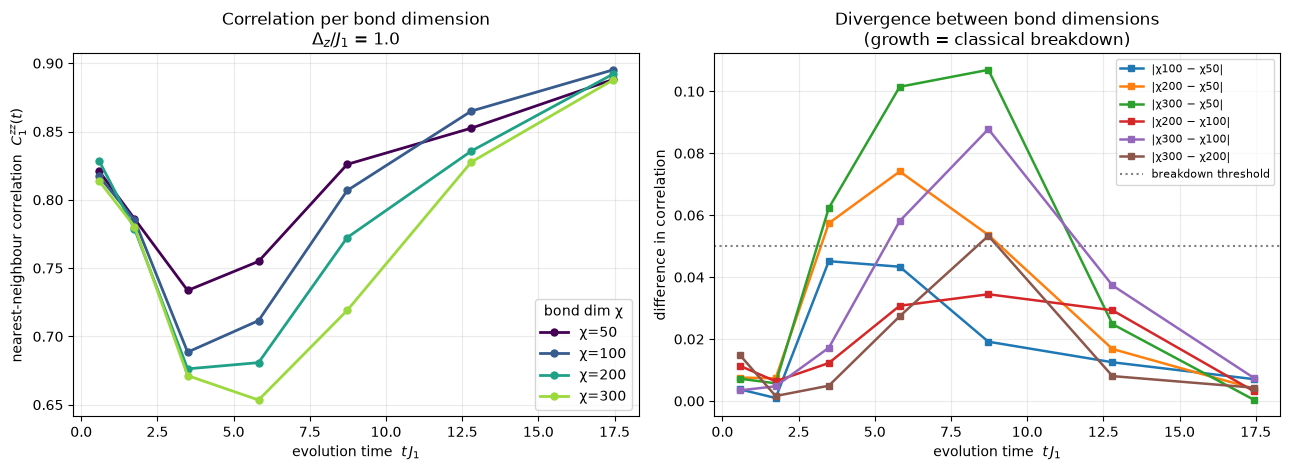

In [11]:
import itertools

def plot_C1_and_divergence(field, fig=None):
    """Left: C1_zz(t) per bond dimension. Right: the difference between them (divergence).
       Left lets the viewer SEE the curves peel apart; right quantifies that spread."""
    t_J1 = SWEEP_TIMES_NS * 1e-3 * (u1 / 4)
    if fig is None:
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
    else:
        axL, axR = fig.subplots(1, 2)

    # LEFT panel: one correlation curve per bond dimension
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(SWEEP_CHI)))
    for chi, col in zip(SWEEP_CHI, colors):
        try:
            y = [C1_all[f"{field}_{int(t)}_{chi}"] for t in SWEEP_TIMES_NS]
        except KeyError:
            continue
        axL.plot(t_J1, y, 'o-', color=col, label=f'χ={chi}', lw=2, ms=5)
    axL.set_xlabel(r'evolution time  $t\,J_1$')
    axL.set_ylabel(r'nearest-neighbour correlation  $C_1^{zz}(t)$')
    axL.set_title(f'Correlation per bond dimension\n$\\Delta_z/J_1$ = {field}')
    axL.grid(alpha=0.25)
    axL.legend(title='bond dim χ')

    # RIGHT panel: the DIFFERENCE between each pair of bond dimensions
    for chi_lo, chi_hi in itertools.combinations(SWEEP_CHI, 2):
        try:
            d = [abs(C1_all[f"{field}_{int(t)}_{chi_hi}"] - C1_all[f"{field}_{int(t)}_{chi_lo}"])
                 for t in SWEEP_TIMES_NS]
        except KeyError:
            continue
        axR.plot(t_J1, d, 's-', label=f'|χ{chi_hi} − χ{chi_lo}|', lw=1.8, ms=4)
    axR.axhline(0.05, ls=':', color='gray', label='breakdown threshold')
    axR.set_xlabel(r'evolution time  $t\,J_1$')
    axR.set_ylabel('difference in correlation')
    axR.set_title('Divergence between bond dimensions\n(growth = classical breakdown)')
    axR.grid(alpha=0.25)
    axR.legend(fontsize=8)
    return fig

# static version for one field
plot_C1_and_divergence(1.0)
plt.tight_layout(); plt.show()

## Reading the result

**Left — C₁ᶻᶻ(t) per χ.** The correlation dips (t·J₁ ≈ 3–4) then recovers. Curves overlap at early
times (weak entanglement, every χ accurate), separate through the intermediate window (χ=50 departs
most, χ=300 least), then reconverge at late times.

**Right — divergence between χ.** A clear rise-and-fall. The widest pairs peak highest and cross
threshold: |χ300 − χ50| reaches ≈0.11 and |χ300 − χ100| ≈0.088, both well above threshold through
t·J₁ ≈ 5–10. The narrowest high-χ pair, |χ300 − χ200|, only just grazes threshold — the two largest
bond dimensions largely agree, indicating χ ≥ 200 is close to converged. So χ=50's divergence is a
genuine departure from a trustworthy reference, not two poor approximations disagreeing.

 The **rise** is the real signal: entanglement grows, low χ can no longer represent the state, emulations diverge — the onset of classical intractability,
and it scales cleanly with the χ gap (wider gap → larger divergence). The **rapid decay is a
finite-size recurrence, not classical catch-up**: at 49 atoms the state partially returns to its
start, entanglement drops, and even χ=50 works again. At 256 qubits this recurrence is pushed far
out and the breakdown is sustained.

In [1]:
from ipywidgets import interact, SelectionSlider

field_slider = SelectionSlider(
    options=[(f'Δz/J1 = {f}', f) for f in SWEEP_FIELDS],
    description='quench field',
    style={'description_width': 'initial'},
    continuous_update=False,
)

@interact(field=field_slider)
def show(field):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
    # reuse the plotting logic by drawing into the existing axes
    t_J1 = SWEEP_TIMES_NS * 1e-3 * (u1 / 4)
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(SWEEP_CHI)))
    for chi, col in zip(SWEEP_CHI, colors):
        try:
            y = [C1_all[f"{field}_{int(t)}_{chi}"] for t in SWEEP_TIMES_NS]
        except KeyError:
            continue
        axL.plot(t_J1, y, 'o-', color=col, label=f'χ={chi}', lw=2, ms=5)
    axL.set_xlabel(r'evolution time  $t\,J_1$'); axL.set_ylabel(r'$C_1^{zz}(t)$')
    axL.set_title(f'Correlation per bond dimension  ($\\Delta_z/J_1$={field})')
    axL.grid(alpha=0.25); axL.legend(title='χ')

    for chi_lo, chi_hi in itertools.combinations(SWEEP_CHI, 2):
        try:
            d = [abs(C1_all[f"{field}_{int(t)}_{chi_hi}"] - C1_all[f"{field}_{int(t)}_{chi_lo}"])
                 for t in SWEEP_TIMES_NS]
        except KeyError:
            continue
        axR.plot(t_J1, d, 's-', label=f'|χ{chi_hi}−χ{chi_lo}|', lw=1.8, ms=4)
    axR.axhline(0.05, ls=':', color='gray', label='threshold')
    axR.set_xlabel(r'evolution time  $t\,J_1$'); axR.set_ylabel('difference in correlation')
    axR.set_title('Divergence between bond dimensions')
    axR.grid(alpha=0.25); axR.legend(fontsize=8)
    plt.tight_layout(); plt.show()

NameError: name 'SWEEP_FIELDS' is not defined

## Field dependence

Entanglement generation should be strongest for quenches *near* the quantum phase transition
(Δz/J₁ ≈ 3.9), so we expected the classical breakdown to grow toward Δz/J₁ ≈ 4. Our sweep does not
show this cleanly: the divergence crosses threshold at low field and again near 4.0, but not
monotonically in between.

We cannot fully explain this. A likely confound is the **finite-size recurrence**: at 49 atoms each
field peaks and recurs at a different time, so whether a given quench clears threshold depends
partly on recurrence timing within our window, not only on the entanglement it generates. This
could mask or distort the expected trend. Distinguishing genuine field-dependent structure from a
finite-size artifact would require larger systems — a natural direction the simulator is well
suited to explore, and one beyond the single-quench demonstration in the paper.